# Selector Group Chat
`SelectorGroupChat` implements a team where participants take turns broadcasting messages to all other members. A generative model (e.g., an LLM) selects the next speaker based on the shared context, enabling dynamic, context-aware collaboration.

Key features include:
- Model-based speaker selection

- Configurable participant roles and descriptions

- Prevention of consecutive turns by the same speaker (optional)

- Customizable selection prompting

- Customizable selection function to override the default model-based selection

- Customizable candidate function to narrow-down the set of agents for selection using model

***Reference URL***

https://microsoft.github.io/autogen/stable//user-guide/agentchat-user-guide/selector-group-chat.html

***Agents***

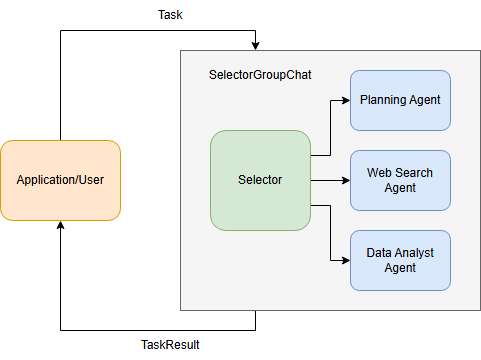

In [37]:
import asyncio
from autogen_ext.models.openai import OpenAIChatCompletionClient
from autogen_agentchat.agents import AssistantAgent
from autogen_agentchat.teams import SelectorGroupChat
from autogen_agentchat.messages import TextMessage
from autogen_agentchat.conditions import TextMentionTermination,MaxMessageTermination

In [38]:
import os
from dotenv import load_dotenv

# Load API key
load_dotenv()
api_key = os.getenv('OPENAI_API_KEY')

In [39]:
# Model Client

model_client= OpenAIChatCompletionClient(model='gpt-4o')
model_client

In [40]:
# Planning Assistant Agent

planning_agent= AssistantAgent(
    name="PlanningAgent",
    description="An agent for planning tasks, this agent should be the first to engage when given a new task.",
    system_message="""
    You are a planning agent.
    Your job is to break down complex tasks into smaller, manageable subtasks.
    Your team members are:
        WebSearchAgent: Searches for information
        DataAnalystAgent: Performs calculations

    You only plan and delegate tasks - you do not execute them yourself.

    When assigning tasks, use this format:
    1. <agent> : <task>

    After all tasks are complete, summarize the findings and end with "TERMINATE".
    """,
    model_client=model_client
)

In [41]:
# Search Web Tool

def search_web_tool(query: str) -> str:
    # Simulate a web search
    if "2006-2007" in query:
        return """Here are the total points scored by Miami Heat players in the 2006-2007 season:
        Udonis Haslem: 844 points
        Dwayne Wade: 1397 points
        James Posey: 550 points
        ...
        """
    elif "2007-2008" in query:
        return "The number of total rebounds for Dwayne Wade in the Miami Heat season 2007-2008 is 214."
    elif "2008-2009" in query:
        return "The number of total rebounds for Dwayne Wade in the Miami Heat season 2008-2009 is 398."
    return "No data found."

In [42]:
# Web Search Assistant Agent

web_search_agent= AssistantAgent(
    name="WebSearchAgent",
    description="An agent for searching the web for information.",
    system_message="""
        You are a web search agent.
        Your only tool is search_web_tool - use it to find the information you need.
        You make only one search call at a time.   
        Once you have the results, you never do calculations or data analysis on them.
    """,
    model_client=model_client,
    tools= [search_web_tool]
)

In [43]:
def percentage_change_tool(start:float, end:float) -> float:
    '''Calculate percentage change'''
    
    if start == 0:
        return 0
    return ((end - start) / start) * 100

In [45]:
# Data Analyst Assistant Agent

data_analyst_agent= AssistantAgent(
    name="DataAnalystAgent",
    description="An agent for performing calculations and data analysis.",
    system_message="""
        You are a data analyst agent.
        Given the tasks you have been assigned, you should analyze the data and provide results using the tools provided.
        If you have not seen the data, ask for it.
    """,
    model_client=model_client,
    tools= [percentage_change_tool]
)

# Termination Condition

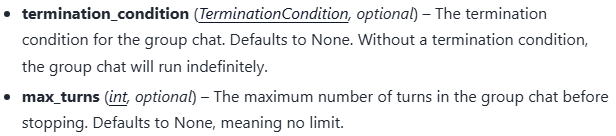

***References***

https://microsoft.github.io/autogen/stable//reference/python/autogen_agentchat.conditions.html

In [46]:
# Termination Condition
from autogen_agentchat.conditions import TextMentionTermination, MaxMessageTermination

text_mention_termination= TextMentionTermination(text="TERMINATE")
max_message_termination= MaxMessageTermination(max_messages=20)

combined_termination= text_mention_termination | max_message_termination

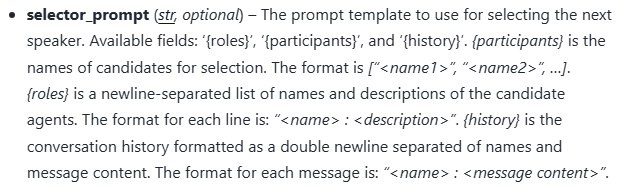

***Reference***

https://microsoft.github.io/autogen/stable//reference/python/autogen_agentchat.teams.html

In [47]:
selector_prompt='''

Select an agent to perform the task.

{roles}

current conversation history :
{history}

Read the above conversation, then select an agent from {participants} to perform the next task.
Make sure that the planning agent has assigned task before other agents start working.
Only select one agent.
'''

In [48]:
# Define Selector Teams

selector_team= SelectorGroupChat(
    participants=[planning_agent, web_search_agent, data_analyst_agent],
    model_client=model_client,
    termination_condition=combined_termination,
    selector_prompt=selector_prompt,
    allow_repeated_speaker=True
)

**description** parameter is mandatory to describe about agent during `SelectorGroupChat`, Not mandatory for `RoundRobinGroupChat`

In [32]:
planning_agent.description

'An agent for planning tasks, this agent should be the first to engage when given a new task.'

In [33]:
web_search_agent.description

'An agent for searching the web for information.'

In [34]:
data_analyst_agent.description

'An agent for performing calculations and data analysis.'

In [49]:
task= "Who was the Miami Heat player with the highest point in the 2006-2007 season, and what was the percentage change in his total rebounds between the 2007-2008 and 2008-2009 seasons?"
task

'Who was the Miami Heat player with the highest point in the 2006-2007 season, and what was the percentage change in his total rebounds between the 2007-2008 and 2008-2009 seasons?'

In [ ]:
'Who was the Miami Heat player with the highest point in the 2006-2007 season, and what was the percentage change in his total rebounds between the 2007-2008 and 2008-2009 seasons?'

***Reference***

https://microsoft.github.io/autogen/stable//reference/python/autogen_agentchat.ui.html

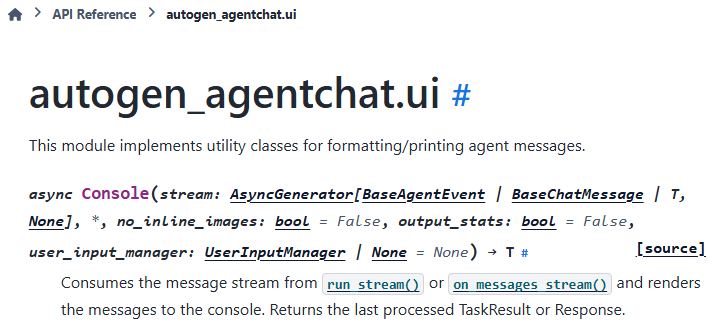

In [53]:
from autogen_agentchat.ui import Console

In [55]:
await Console(selector_team.run_stream(task=task))

---------- TextMessage (user) ----------
Who was the Miami Heat player with the highest point in the 2006-2007 season, and what was the percentage change in his total rebounds between the 2007-2008 and 2008-2009 seasons?
---------- TextMessage (PlanningAgent) ----------
To answer the questions, we need to undertake the following subtasks:

1. WebSearchAgent: Identify the Miami Heat player with the highest points in the 2006-2007 NBA season.
2. WebSearchAgent: Find the player's total rebounds for the 2007-2008 NBA season.
3. WebSearchAgent: Find the player's total rebounds for the 2008-2009 NBA season.
4. DataAnalystAgent: Calculate the percentage change in the player's total rebounds between the 2007-2008 and 2008-2009 seasons.

Let's begin with the search tasks:

1. WebSearchAgent: Identify the Miami Heat player with the highest points in the 2006-2007 NBA season.
---------- ToolCallRequestEvent (WebSearchAgent) ----------
[FunctionCall(id='call_NXp29v6le70L5RAdTM9kIZjt', arguments='{

TaskResult(messages=[TextMessage(id='1f7f575f-0c20-4d76-bbd9-502c19a768db', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 13, 12, 8, 34, 959996, tzinfo=datetime.timezone.utc), content='Who was the Miami Heat player with the highest point in the 2006-2007 season, and what was the percentage change in his total rebounds between the 2007-2008 and 2008-2009 seasons?', type='TextMessage'), TextMessage(id='d33be6a3-f2d4-4f7c-be42-b9488454450f', source='PlanningAgent', models_usage=RequestUsage(prompt_tokens=161, completion_tokens=150), metadata={}, created_at=datetime.datetime(2025, 7, 13, 12, 8, 39, 427760, tzinfo=datetime.timezone.utc), content="To answer the questions, we need to undertake the following subtasks:\n\n1. WebSearchAgent: Identify the Miami Heat player with the highest points in the 2006-2007 NBA season.\n2. WebSearchAgent: Find the player's total rebounds for the 2007-2008 NBA season.\n3. WebSearchAgent: Find the player's total rebounds

In [ ]:
TaskResult(messages=[
    TextMessage(id='1f7f575f-0c20-4d76-bbd9-502c19a768db', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 13, 12, 8, 34, 959996, tzinfo=datetime.timezone.utc), content='Who was the Miami Heat player with the highest point in the 2006-2007 season, and what was the percentage change in his total rebounds between the 2007-2008 and 2008-2009 seasons?', type='TextMessage'), 
    
    
    TextMessage(id='d33be6a3-f2d4-4f7c-be42-b9488454450f', source='PlanningAgent', models_usage=RequestUsage(prompt_tokens=161, completion_tokens=150), metadata={}, created_at=datetime.datetime(2025, 7, 13, 12, 8, 39, 427760, tzinfo=datetime.timezone.utc), content="To answer the questions, we need to undertake the following subtasks:\n\n1. WebSearchAgent: Identify the Miami Heat player with the highest points in the 2006-2007 NBA season.\n2. WebSearchAgent: Find the player's total rebounds for the 2007-2008 NBA season.\n3. WebSearchAgent: Find the player's total rebounds for the 2008-2009 NBA season.\n4. DataAnalystAgent: Calculate the percentage change in the player's total rebounds between the 2007-2008 and 2008-2009 seasons.\n\nLet's begin with the search tasks:\n\n1. WebSearchAgent: Identify the Miami Heat player with the highest points in the 2006-2007 NBA season.", type='TextMessage'), 
    
    
    ToolCallRequestEvent(id='ce4fbaa4-df47-480a-932c-1a32497aa85b', source='WebSearchAgent', models_usage=RequestUsage(prompt_tokens=306, completion_tokens=25), metadata={}, created_at=datetime.datetime(2025, 7, 13, 12, 8, 41, 629449, tzinfo=datetime.timezone.utc), content=[FunctionCall(id='call_NXp29v6le70L5RAdTM9kIZjt', arguments='{"query":"Miami Heat leading scorer 2006-2007 season"}', name='search_web_tool')], type='ToolCallRequestEvent'), 
    
    
    ToolCallExecutionEvent(id='42547051-d71e-4567-8ac1-6524c296a144', source='WebSearchAgent', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 13, 12, 8, 41, 632444, tzinfo=datetime.timezone.utc), content=[FunctionExecutionResult(content='Here are the total points scored by Miami Heat players in the 2006-2007 season:\n        Udonis Haslem: 844 points\n        Dwayne Wade: 1397 points\n        James Posey: 550 points\n        ...\n        ', name='search_web_tool', call_id='call_NXp29v6le70L5RAdTM9kIZjt', is_error=False)], type='ToolCallExecutionEvent'), 
    
    
    ToolCallSummaryMessage(id='ab407f11-6cd9-4ea3-8556-26454e4e6a46', source='WebSearchAgent', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 13, 12, 8, 41, 632444, tzinfo=datetime.timezone.utc), content='Here are the total points scored by Miami Heat players in the 2006-2007 season:\n        Udonis Haslem: 844 points\n        Dwayne Wade: 1397 points\n        James Posey: 550 points\n        ...\n        ', type='ToolCallSummaryMessage', tool_calls=[FunctionCall(id='call_NXp29v6le70L5RAdTM9kIZjt', arguments='{"query":"Miami Heat leading scorer 2006-2007 season"}', name='search_web_tool')], results=[FunctionExecutionResult(content='Here are the total points scored by Miami Heat players in the 2006-2007 season:\n        Udonis Haslem: 844 points\n        Dwayne Wade: 1397 points\n        James Posey: 550 points\n        ...\n        ', name='search_web_tool', call_id='call_NXp29v6le70L5RAdTM9kIZjt', is_error=False)]), 
    
    
    ThoughtEvent(id='9a27eb39-9c4b-4926-9254-468cfd8d2459', source='WebSearchAgent', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 13, 12, 8, 44, 996867, tzinfo=datetime.timezone.utc), content="The Miami Heat player with the highest points in the 2006-2007 season was Dwayne Wade, with 1,397 points.\n\nNext, let's find out Dwayne Wade's total rebounds for the 2007-2008 and 2008-2009 seasons.", type='ThoughtEvent'), 
    
    ToolCallRequestEvent(id='dbfb5c36-f51a-4193-ba3d-3a34e0d31558', source='WebSearchAgent', models_usage=RequestUsage(prompt_tokens=393, completion_tokens=126), metadata={}, created_at=datetime.datetime(2025, 7, 13, 12, 8, 44, 996867, tzinfo=datetime.timezone.utc), content=[FunctionCall(id='call_NiLkmIWiXC33P2seIwpCgVmc', arguments='{"query": "Dwayne Wade total rebounds 2007-2008 season"}', name='search_web_tool'), FunctionCall(id='call_UVUm6tpyF4M3yuc914XyG56R', arguments='{"query": "Dwayne Wade total rebounds 2008-2009 season"}', name='search_web_tool')], type='ToolCallRequestEvent'), 
    
    
    ToolCallExecutionEvent(id='3a48a162-97c5-44d7-a5a6-2767ff9f3a5f', source='WebSearchAgent', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 13, 12, 8, 45, 1384, tzinfo=datetime.timezone.utc), content=[FunctionExecutionResult(content='The number of total rebounds for Dwayne Wade in the Miami Heat season 2007-2008 is 214.', name='search_web_tool', call_id='call_NiLkmIWiXC33P2seIwpCgVmc', is_error=False), FunctionExecutionResult(content='The number of total rebounds for Dwayne Wade in the Miami Heat season 2008-2009 is 398.', name='search_web_tool', call_id='call_UVUm6tpyF4M3yuc914XyG56R', is_error=False)], type='ToolCallExecutionEvent'), 
    
    
    ToolCallSummaryMessage(id='56270fca-7fa0-4488-96bf-6ac47b8ff75a', source='WebSearchAgent', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 13, 12, 8, 45, 1384, tzinfo=datetime.timezone.utc), content='The number of total rebounds for Dwayne Wade in the Miami Heat season 2007-2008 is 214.\nThe number of total rebounds for Dwayne Wade in the Miami Heat season 2008-2009 is 398.', type='ToolCallSummaryMessage', tool_calls=[FunctionCall(id='call_NiLkmIWiXC33P2seIwpCgVmc', arguments='{"query": "Dwayne Wade total rebounds 2007-2008 season"}', name='search_web_tool'), FunctionCall(id='call_UVUm6tpyF4M3yuc914XyG56R', arguments='{"query": "Dwayne Wade total rebounds 2008-2009 season"}', name='search_web_tool')], results=[FunctionExecutionResult(content='The number of total rebounds for Dwayne Wade in the Miami Heat season 2007-2008 is 214.', name='search_web_tool', call_id='call_NiLkmIWiXC33P2seIwpCgVmc', is_error=False), FunctionExecutionResult(content='The number of total rebounds for Dwayne Wade in the Miami Heat season 2008-2009 is 398.', name='search_web_tool', call_id='call_UVUm6tpyF4M3yuc914XyG56R', is_error=False)]), 
    
    
    ToolCallRequestEvent(id='361ab285-1c90-4a24-a1dd-b90a0c9cee84', source='DataAnalystAgent', models_usage=RequestUsage(prompt_tokens=424, completion_tokens=20), metadata={}, created_at=datetime.datetime(2025, 7, 13, 12, 8, 46, 478455, tzinfo=datetime.timezone.utc), content=[FunctionCall(id='call_TcKvURJLzXzrdUOw1YX8uaO0', arguments='{"start":214,"end":398}', name='percentage_change_tool')], type='ToolCallRequestEvent'), 
    
    
    ToolCallExecutionEvent(id='d7a5628a-0fb8-4e26-9962-4c0c34cf8d6d', source='DataAnalystAgent', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 13, 12, 8, 46, 480455, tzinfo=datetime.timezone.utc), content=[FunctionExecutionResult(content='85.98130841121495', name='percentage_change_tool', call_id='call_TcKvURJLzXzrdUOw1YX8uaO0', is_error=False)], type='ToolCallExecutionEvent'), 
    
    
    ToolCallSummaryMessage(id='63e15257-a6d3-4451-88fa-3f9b093c626d', source='DataAnalystAgent', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 13, 12, 8, 46, 480455, tzinfo=datetime.timezone.utc), content='85.98130841121495', type='ToolCallSummaryMessage', tool_calls=[FunctionCall(id='call_TcKvURJLzXzrdUOw1YX8uaO0', arguments='{"start":214,"end":398}', name='percentage_change_tool')], results=[FunctionExecutionResult(content='85.98130841121495', name='percentage_change_tool', call_id='call_TcKvURJLzXzrdUOw1YX8uaO0', is_error=False)]), 
    
    
    TextMessage(id='74ab889e-91d8-48e1-8552-08a233f5c66b', source='PlanningAgent', models_usage=RequestUsage(prompt_tokens=448, completion_tokens=111), metadata={}, created_at=datetime.datetime(2025, 7, 13, 12, 8, 48, 701982, tzinfo=datetime.timezone.utc), content="Based on the information gathered:\n\n- The Miami Heat player with the highest points in the 2006-2007 season was Dwayne Wade with 1397 points.\n- Total rebounds for Dwayne Wade in the 2007-2008 season were 214.\n- Total rebounds for Dwayne Wade in the 2008-2009 season were 398.\n- The percentage change in Dwayne Wade's total rebounds between the 2007-2008 and 2008-2009 seasons is approximately 86.0%.\n\nTERMINATE", type='TextMessage')], 

stop_reason="Text 'TERMINATE' mentioned")
